# 1. Training

## 1.1 Preprocessing

In [11]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch, lfilter, medfilt, find_peaks
import joblib

# ── 1) LOAD YOUR DATA
df = pd.read_csv('df.csv')

# ── 2) SETUP FILTERS & PARAMETERS
fs = 125 # Hz sampling rate

# (a) Baseline-wander high-pass
def highpass_filter(x, cutoff=0.5, fs=fs, order=2):
    b, a = butter(order, cutoff/(0.5*fs), btype='high')
    return filtfilt(b, a, x)
    
# (b) Notch at mains frequency
def notch_filter(x, fs=fs, f0=50.0, Q=30.0):
    b, a = iirnotch(f0/(fs/2), Q)
    return filtfilt(b, a, x)
    
# (c) Pan–Tompkins low-pass: H_lp(z) = (1 - z^-6)^2 / (1 - z^-1)^2
b_lp = np.zeros(13)
b_lp[0] = 1
b_lp[6] = -2
b_lp[12] = 1
# denominator: 1 - 2z^-1 + z^-2
a_lp = np.array([1, -2, 1])

# (d) Pan–Tompkins high-pass: H_hp(z) = z^-16 - (1 - z^-32)/(1 - z^-1)
# Expand numerator: -1 for z^0..z^31, +1 at z^16
b_hp = -np.ones(32)
b_hp[16] += 1
# denominator: 1 - z^-1
a_hp = np.array([1, -1])

# (e) Derivative (5-point) kernel: y[n] = (1/8)[2x(n) + x(n-1) - x(n-3) - 2x(n-4)]
deriv_kernel = np.array([2, 1, 0, -1, -2]) / 8.0

# (f) Moving-window integration (150 ms)
mwi_win = int(0.150 * fs)
mwi_kernel = np.ones(mwi_win) / mwi_win

# ── 3) ECG PREPROCESSING
ecg_raw = df['ECG'].values

# 1) high-pass → notch
ecg_hp = highpass_filter(ecg_raw)
ecg_notch = notch_filter(ecg_hp)

# 2) compute & save global normalization params
ecg_mean = ecg_notch.mean()
ecg_std = ecg_notch.std()
ecg_stats = {
    'mean': ecg_mean,
    'std': ecg_std,
    'min': ecg_notch.min(),
    'max': ecg_notch.max()
}
joblib.dump(ecg_stats, 'params.pkl')

# 3) z-score normalize
ecg_norm = (ecg_notch - ecg_mean) / ecg_std

# 4) Pan–Tompkins filters
# a) low-pass
y_lp = lfilter(b_lp, a_lp, ecg_norm)
# b) high-pass
y_hp = lfilter(b_hp, a_hp, y_lp)
# c) derivative
y_der = np.convolve(y_hp, deriv_kernel, mode='same')
# d) squaring
y_sq = y_der ** 2
# e) moving-window integration
y_mwi = np.convolve(y_sq, mwi_kernel, mode='same')

# 5) store envelope (for QRS detection / features)
df['ecg_preproc'] = y_mwi

# ── 4) EPOCH-LEVEL ABP EXTRACTION
epoch_sec = 20
samples_per_epoch = fs * epoch_sec
# median filter kernel for ABP (0.2 s)
kernel = int(0.2 * fs)
if kernel % 2 == 0:
    kernel += 1
    
epoch_indices = []
epoch_sbp, epoch_dbp = [], []
num_epochs = len(df) // samples_per_epoch

for i in range(num_epochs):
    start = i * samples_per_epoch
    end = start + samples_per_epoch
    epoch_indices.append((start, end))
    
    abp_seg = df['ABP'].iloc[start:end].values
    abp_smooth = medfilt(abp_seg, kernel_size=kernel)
    
    # systolic peaks
    locs_s, _ = find_peaks(abp_smooth, distance=int(0.25 * fs))
    vals_s = abp_seg[locs_s]
    
    # diastolic troughs between peaks
    locs_d = []
    for j in range(len(locs_s) - 1):
        seg = abp_smooth[locs_s[j]:locs_s[j+1]]
        if seg.size:
            trough = np.argmin(seg)
            locs_d.append(locs_s[j] + trough)
    vals_d = abp_seg[locs_d]
    
    # median of top-beats
    sbp = np.median(np.sort(vals_s)[-epoch_sec:]) if vals_s.size else np.nan
    dbp = np.median(np.sort(vals_d)[-epoch_sec:]) if vals_d.size else np.nan
    
    epoch_sbp.append(sbp)
    epoch_dbp.append(dbp)
    
# assemble results
epoch_df = pd.DataFrame({'systolic': epoch_sbp, 'diastolic': epoch_dbp})
epoch_df.tail()

,systolic,diastolic
82,95.2,60.8
83,94.4,60.0
84,98.4,62.4
85,96.0,60.8
86,96.8,61.2


## 2.2 Definisi Fungsi

In [12]:
def shape_factor(signal):
    """
    Compute the Shape Factor of a 1D signal array.
    SF = X_rms / ( (1/n) * sum of sqrt(|x_i|) )
    """
    n = len(signal)
    xrms = np.sqrt(np.mean(signal**2))
    # compute mean of sqrt(|x_i|)
    mean_sqrt_abs = np.mean(np.sqrt(np.abs(signal)))
    sf = xrms / mean_sqrt_abs
    return sf

def svd_feature(signal_matrix):
    """
    Compute a feature from the SVD of a 2D 'signal_matrix'.
    For instance, we might return the largest singular value (sigma_1).
    """
    # Perform SVD: X = U * S * V^T
    U, S, Vt = np.linalg.svd(signal_matrix, full_matrices=False)
    # Example: return the largest singular value
    return S[0] # sigma_1

def mean_feature(signal):
    """
    Compute the mean of a 1D signal array.
    Formula:
    mean = (1 / n) * sum(x_i), for i in [1..n]
    """
    return np.mean(signal)

def rms_feature(signal):
    """
    Compute the RMS (root mean square) of a 1D signal array.
    Formula:
    RMS = sqrt( (1/n) * sum(x_i^2) ), for i in [1..n]
    """
    return np.sqrt(np.mean(signal**2))

def average_energy(signal):
    """
    Compute the average energy of a 1D signal array.
    Formula:
    Energy = (1/n) * sum(x_i^2), for i in [1..n]
    Note: This is equivalent to RMS^2.
    """
    return np.mean(signal**2)

def skewness(x):
    """
    Computes the sample skewness of x.
    Formula (for sample skewness):
    skew = [ Σ (x_i - mean_x)^3 ] / [ (n-1) * (std_x^3) ]
    """
    n = len(x)
    mean_x = np.mean(x)
    std_x = np.std(x, ddof=1) # sample standard deviation
    if std_x == 0:
        return 0.0
    skew = np.sum((x - mean_x)**3) / ((n - 1) * (std_x**3))
    return skew

def coefficient_of_variation(x):
    """
    Computes the Coefficient of Variation (CV) of x, in percentage.
    Formula:
    CV = (std_x / mean_x) * 100
    """
    mean_x = np.mean(x)
    std_x = np.std(x, ddof=1)
    if mean_x == 0:
        return 0.0
    return (std_x / mean_x) * 100

def standard_deviation(signal):
    """
    Computes the sample standard deviation of a 1D signal.
    """
    return np.std(signal, ddof=1)

def hjorth_activity(signal):
    """
    Hjorth Activity is the variance of the signal.
    """
    return np.var(signal, ddof=1)

def hjorth_mobility(signal):
    """
    Hjorth Mobility = sqrt( Var(d/dt(signal)) / Var(signal) )
    """
    activity = hjorth_activity(signal)
    if activity == 0:
        return 0.0
    first_deriv = np.diff(signal)
    return np.sqrt(np.var(first_deriv, ddof=1) / activity)

def hjorth_complexity(signal):
    """
    Hjorth Complexity = (Mobility of first derivative) / (Mobility of original signal).
    Equivalent to:
    sqrt(
    [Var(d^2/dt^2(signal)) / Var(d/dt(signal))] /
    [Var(d/dt(signal)) / Var(signal)]
    )
    """
    activity = hjorth_activity(signal)
    mob = hjorth_mobility(signal)
    if mob == 0:
        return 0.0
        
    first_deriv = np.diff(signal)
    second_deriv = np.diff(first_deriv)
    var_first = np.var(first_deriv, ddof=1)
    var_second = np.var(second_deriv, ddof=1)
    
    if var_first == 0:
        return 0.0
        
    return np.sqrt((var_second / var_first) / (var_first / activity))

def central_moment_10(x):
    """
    Computes the 10th central moment of x.
    Formula (general nth central moment):
    CM_n = (1/n) * Σ (x_i - mean_x)^n
    Here we use n=10 by default.
    """
    mean_x = np.mean(x)
    return np.mean((x - mean_x)**10)

## 1.3 Ekstraksi Fitur

In [13]:
# 1. Create lists to store features for each epoch
ecg_means = []
ecg_rms_vals = []
ecg_energy_vals = []
ecg_sf_vals = []
ecg_svd_vals = []

# -- New features --
ecg_skewness_vals = []
ecg_cv_vals = []
ecg_activity_vals = []
ecg_mobility_vals = []
ecg_cm10_vals = []
ecg_complexity_vals = []
ecg_std_vals = []

# 2. Loop over each epoch, extract features
for (start, end) in epoch_indices:
    ecg_epoch = df['ecg_preproc'].iloc[start:end].values
    # Existing features
    val_mean = mean_feature(ecg_epoch)
    val_rms = rms_feature(ecg_epoch)
    val_energy = average_energy(ecg_epoch)
    val_sf = shape_factor(ecg_epoch)
    ecg_2d = ecg_epoch.reshape(-1, 1)
    val_svd = svd_feature(ecg_2d)
    # New features
    val_skew = skewness(ecg_epoch)
    val_cv = coefficient_of_variation(ecg_epoch)
    val_activity = hjorth_activity(ecg_epoch)
    val_mobility = hjorth_mobility(ecg_epoch)
    val_cm10 = central_moment_10(ecg_epoch)
    val_complexity = hjorth_complexity(ecg_epoch)
    val_std = standard_deviation(ecg_epoch)
    # Append to lists
    ecg_means.append(val_mean)
    ecg_rms_vals.append(val_rms)
    ecg_energy_vals.append(val_energy)
    ecg_sf_vals.append(val_sf)
    ecg_svd_vals.append(val_svd)
    ecg_skewness_vals.append(val_skew)
    ecg_cv_vals.append(val_cv)
    ecg_activity_vals.append(val_activity)
    ecg_mobility_vals.append(val_mobility)
    ecg_cm10_vals.append(val_cm10)
    ecg_complexity_vals.append(val_complexity)
    ecg_std_vals.append(val_std)

# 3. Rebuild epoch_df to include epoch_start, epoch_end, BPs, and new features
epoch_df = pd.DataFrame({
    'systolic': epoch_df['systolic'],
    'diastolic': epoch_df['diastolic'],
    'ecg_mean': ecg_means,
    'ecg_rms': ecg_rms_vals,
    'ecg_energy': ecg_energy_vals,
    'ecg_sf': ecg_sf_vals,
    'ecg_svd': ecg_svd_vals,
    'ecg_skewness': ecg_skewness_vals,
    'ecg_cv': ecg_cv_vals,
    'ecg_activity': ecg_activity_vals,
    'ecg_mobility': ecg_mobility_vals,
    'ecg_cm10': ecg_cm10_vals,
    'ecg_complexity': ecg_complexity_vals,
    'ecg_std': ecg_std_vals
})

epoch_df.tail()

,systolic,diastolic,ecg_mean,ecg_rms,ecg_energy,ecg_sf,ecg_svd,ecg_skewness,ecg_cv,ecg_activity,ecg_mobility,ecg_cm10,ecg_complexity,ecg_std
82,95.2,60.8,189878.844610,261814.723454,6.854695e+10,703.137235,1.309074e+07,0.717291,94.952199,3.250598e+10,0.134153,5.157380e+55,1.389994,180294.137944
83,94.4,60.0,178815.923772,244758.763382,5.990685e+10,675.242609,1.223794e+07,0.549517,93.482325,2.794289e+10,0.136887,1.147936e+54,1.363937,167161.283842
84,98.4,62.4,184684.511487,254470.191774,6.475508e+10,691.442308,1.272351e+07,0.713025,94.808730,3.065897e+10,0.134012,3.632285e+55,1.392449,175097.039688
85,96.0,60.8,180319.053675,249447.204339,6.222391e+10,689.435085,1.247236e+07,0.681525,95.606822,2.972083e+10,0.134488,3.069582e+55,1.385414,172397.317172
86,96.8,61.2,192007.471797,281623.782217,7.931195e+10,754.477094,1.408119e+07,2.762168,107.320442,4.246207e+10,0.179145,1.325891e+60,4.699444,206063.267742


## 1.4 Pelatihan Model

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------
# 1) Define feature & target columns
# ----------------------------------
# Suppose you have these columns in epoch_df (including the ones you want to scale)
feature_columns = [
"ecg_mean", "ecg_sf", "ecg_mobility","ecg_skewness", "ecg_cv", "ecg_complexity", "ecg_cm10"
]

# Targets
target_sbp = "systolic"
target_dbp = "diastolic"

# Bersihkan
epoch_df.dropna(inplace=True)

# ----------------------------------
# 2) Split into X, y
# ----------------------------------
X = epoch_df[feature_columns].copy() # copy so we can safely modify
y_sbp = epoch_df[target_sbp].values
y_dbp = epoch_df[target_dbp].values

# ----------------------------------
# 3) Train-Test Split
# ----------------------------------
X_train, X_test, y_sbp_train, y_sbp_test = train_test_split(X, y_sbp, test_size=0.2, random_state=42)

# For DBP, use the same split indices:
_, _, y_dbp_train, y_dbp_test = train_test_split(
    X, y_dbp, test_size=0.2, random_state=42
)

from sklearn.preprocessing import MinMaxScaler
import joblib

# ─── 4) SCALE FEATURES
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit on train only
X_test_scaled = scaler.transform(X_test) # same transform on test

# save for live inference
joblib.dump(scaler, 'feat_scaler.pkl')

from sklearn.ensemble import RandomForestRegressor

# Define the hyperparameters
params = {
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_split': 2,
    'n_estimators': 500
}

# Train Random Forest Regression for Systolic BP
rf_sbp = RandomForestRegressor(random_state=42)
rf_sbp.fit(X_train_scaled, y_sbp_train)

# Train Random Forest Regression for Diastolic BP
rf_dbp = RandomForestRegressor(random_state=42)
rf_dbp.fit(X_train_scaled, y_dbp_train)

joblib.dump(rf_sbp, "rf2_sbp.pkl") 
joblib.dump(rf_dbp, "rf2_dbp.pkl")

print("Model SBP dan DBP berhasil disimpan!")

# Prediksi menggunakan data test
y_sbp_pred = rf_sbp.predict(X_test_scaled)
y_dbp_pred = rf_dbp.predict(X_test_scaled)

# Hitung MAE
mae_sbp_offline = mean_absolute_error(y_sbp_test, y_sbp_pred)
mae_dbp_offline = mean_absolute_error(y_dbp_test, y_dbp_pred)

print(f"MAE SBP (Offline): {mae_sbp_offline:.2f} mmHg")
print(f"MAE DBP (Offline): {mae_dbp_offline:.2f} mmHg")

mape_sbp_offline = np.mean(np.abs((y_sbp_test - y_sbp_pred) / y_sbp_test)) * 100
mape_dbp_offline = np.mean(np.abs((y_dbp_test - y_dbp_pred) / y_dbp_test)) * 100

print(f"MAPE SBP (Offline): {mape_sbp_offline:.2f}%")
print(f"MAPE DBP (Offline): {mape_dbp_offline:.2f}%")

Model SBP dan DBP berhasil disimpan!
MAE SBP (Offline): 2.77 mmHg
MAE DBP (Offline): 2.07 mmHg
MAPE SBP (Offline): 3.00%
MAPE DBP (Offline): 3.57%


# 2. Sistem

## 2.1 Inisialisasi Sistem

In [15]:
import sys
import time
from collections import deque
import warnings
import numpy as np
import pandas as pd
import serial
#from serial import SerialException
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import joblib
#from pyshimmer import ShimmerBluetooth, DEFAULT_BAUDRATE, DataPacket, EChannelType
# ————— SUPPRESS SCALER WARNING —————
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but MinMaxScaler was fitted with feature names"
)
# ————— CONFIG —————
PORT = 'COM3' # port serial
FS = 125 # sampling rate [Hz]
BUF_SEC = 20 # detik untuk buffer
BUF_SZ = FS * BUF_SEC
V_REF = 2.42 # referensi tegangan [V]
GAIN = 4 # gain amplifier
SENS_MV = V_REF / (GAIN * (2**23 - 1)) * 1000 # mV per ADC count
#CH_ECG = EChannelType.EXG_ADS1292R_1_CH1_24BIT # channel ECG
# ————— LOAD MODELS & SCALERS —————
model_sbp = joblib.load("rf2_sbp.pkl") # trained RF for SBP

model_dbp = joblib.load("rf2_dbp.pkl") # trained RF for DBP
feat_scaler = joblib.load("feat_scaler.pkl")# feature-level scaler
ecg_stats = joblib.load("params.pkl") # global envelope stats (if needed)
# ————— BUFFER & COUNTER —————
buf = deque(maxlen=BUF_SZ)
sample_count = 0
def to_signed24(x):
    return x - 0x1000000 if (x & 0x800000) else x



# SIMULASI
df_sim = pd.read_csv('df.csv')
sim_data = df_sim['ECG'].values # Ambil kolom ECG
sim_idx = 0

# Tambahkan mwi_kernel (di Kode 5 Mas Ilham dipakai tapi belum didefinisikan di snippetmu)
mwi_win = int(0.150 * FS)
mwi_kernel = np.ones(mwi_win) / mwi_win

# Buffer tetap sama
buf = deque(maxlen=BUF_SZ)
sample_count = 0

## 2.2 Callback Data Stream

In [16]:
# GANTI SELURUH KODE 2 DENGAN INI:
def simulate_stream():
    global sample_count, sim_idx
    # Simulasi data datang 1 sampel
    if sim_idx < len(sim_data):
        val = sim_data[sim_idx]
        buf.append(val)
        sample_count += 1
        sim_idx += 1

## 2.3 Definisi Fungsi Ekstraksi Fitur

In [17]:
def mean_feature(x):
    return np.mean(x)
    
def shape_factor(x):
    xrms = np.sqrt(np.mean(x**2))
    msa = np.mean(np.sqrt(np.abs(x)))
    return xrms/msa if msa else 0.0

def mobility(x):
    vs = np.var(x, ddof=1)
    vd = np.var(np.diff(x), ddof=1) if x.size > 1 else 0.0
    return np.sqrt(vd/vs) if vs else 0.0
    
def complexity(x):
    vs = np.var(x, ddof=1)
    d1 = np.diff(x)
    v1 = np.var(d1, ddof=1) if d1.size > 1 else 0.0
    d2 = np.diff(d1)
    v2 = np.var(d2, ddof=1) if d2.size > 1 else 0.0
    return np.sqrt((v2/v1)/(v1/vs)) if vs and v1 else 0.0
    
def skewness(x):
    n = x.size
    mu = np.mean(x)
    s = np.std(x, ddof=1)
    return np.sum((x-mu)**3)/((n-1)*s**3) if s and n > 1 else 0.0
    
def coef_var(x):
    mu = np.mean(x)
    s = np.std(x, ddof=1)
    return (s/mu)*100 if mu else 0.0

def cm10(x):
    mu = np.mean(x)
    return np.mean((x-mu)**10)

## 2.4 Visualisasi dan Tabel

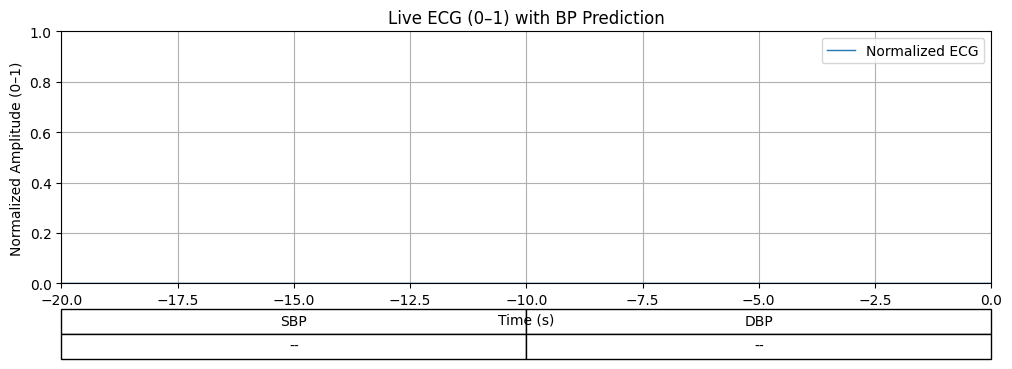

In [18]:
# ————— PLOT SETUP —————
t = np.linspace(-BUF_SEC, 0, BUF_SZ)
fig, ax = plt.subplots(figsize=(12, 4))
fig.subplots_adjust(bottom=0.25)

line_norm, = ax.plot(t, np.zeros(BUF_SZ), lw=1, label="Normalized ECG")
ax.set_title("Live ECG (0–1) with BP Prediction")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized Amplitude (0–1)")
ax.set_xlim(-BUF_SEC, 0)
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
ax.grid(True)

# ————— ADD TABLE UNDER GRAPH —————
table = ax.table(
    cellText=[["--", "--"]],
    colLabels=["SBP", "DBP"],
    cellLoc="center",
    loc="bottom",
    bbox=[0, -0.3, 1, 0.2]
)

## 2.5 Loop Utama dan Prediksi

In [19]:
# --- SIMULASI MODE PRINT (VERSI BERSIH) ---
print(f"Memulai simulasi... Mengolah data: {len(sim_data)} sampel.")
print("-" * 50)

try:
    # Reset index simulasi
    sim_idx = 0
    sample_count = 0
    buf.clear()

    while sim_idx < len(sim_data):
        # 1. Simulasi data masuk (misal 1 detik data setiap iterasi)
        for _ in range(FS): 
            simulate_stream()
        
        # 2. Syarat Buffer 20 Detik [cite: 524]
        if sample_count >= BUF_SZ:
            # --- PREPROCESSING & ENVELOPE ---
            raw = np.array(buf)
            mn_r, mx_r = raw.min(), raw.max()
            norm = (raw - mn_r)/(mx_r - mn_r) if mx_r > mn_r else np.zeros_like(raw)
            
            # Envelope via MWI [cite: 463, 1046]
            env = np.convolve(norm**2, mwi_kernel, mode="same")
            
            # --- FEATURE EXTRACTION (7 Fitur) [cite: 120] ---
            feats = np.array([
                mean_feature(env), shape_factor(env), mobility(env),
                skewness(env), coef_var(env), complexity(env), cm10(env)
            ]).reshape(1, -1)
            
            # --- SCALE & PREDICT [cite: 1047] ---
            cols = (feat_scaler.feature_names_in_ if hasattr(feat_scaler, "feature_names_in_") else [f"f{i}" for i in range(feats.shape[1])])
            feats_df = pd.DataFrame(feats, columns=cols)
            feats_scaled = feat_scaler.transform(feats_df)
            
            sbp_pred = model_sbp.predict(feats_scaled)[0]

            # 1. Deteksi Puncak R menggunakan hasil Pan-Tompkins (env/y_mwi)
            peaks, _ = find_peaks(env, distance=int(0.6 * FS), height=np.mean(env))

            # 2. Hitung Heart Rate (HR)
            num_beats = len(peaks)
            hr_pred = (num_beats / BUF_SEC) * 60

            # 3. Hitung Rate Pressure Product (RPP)
            # RPP = HR * SBP
            rpp_pred = hr_pred * sbp_pred

            print(f"Detik ke-{sim_idx/FS:5.1f} | SBP: {sbp_pred:5.1f} | HR: {hr_pred:5.1f} | RPP: {rpp_pred:7.1f}")
            
        # Atur jeda simulasi (0.1s agar terasa live)
        time.sleep(0.1)

except KeyboardInterrupt:
    print("\nSimulasi dihentikan.")
finally:
    print("-" * 50)
    print("Simulasi selesai.")

Memulai simulasi... Mengolah data: 217500 sampel.
--------------------------------------------------
Detik ke- 20.0 | SBP:  93.2 | HR:  72.0 | RPP:  6711.3
Detik ke- 21.0 | SBP:  93.2 | HR:  75.0 | RPP:  6990.9
Detik ke- 22.0 | SBP:  93.2 | HR:  75.0 | RPP:  6990.9
Detik ke- 23.0 | SBP:  93.2 | HR:  75.0 | RPP:  6990.9
Detik ke- 24.0 | SBP:  93.2 | HR:  75.0 | RPP:  6987.9
Detik ke- 25.0 | SBP:  93.2 | HR:  72.0 | RPP:  6708.4
Detik ke- 26.0 | SBP:  93.1 | HR:  75.0 | RPP:  6984.9
Detik ke- 27.0 | SBP:  92.8 | HR:  75.0 | RPP:  6962.1
Detik ke- 28.0 | SBP:  92.8 | HR:  75.0 | RPP:  6963.3
Detik ke- 29.0 | SBP:  92.9 | HR:  72.0 | RPP:  6687.6
Detik ke- 30.0 | SBP:  93.1 | HR:  75.0 | RPP:  6980.7
Detik ke- 31.0 | SBP:  93.1 | HR:  75.0 | RPP:  6980.7
Detik ke- 32.0 | SBP:  93.0 | HR:  75.0 | RPP:  6975.3
Detik ke- 33.0 | SBP:  93.1 | HR:  72.0 | RPP:  6701.5
Detik ke- 34.0 | SBP:  93.1 | HR:  72.0 | RPP:  6705.5
Detik ke- 35.0 | SBP:  93.2 | HR:  75.0 | RPP:  6990.9
Detik ke- 36.0 | SB